# PSFFieldEPSF visualisation

Visual + quantitative check on the production PSF model. Section ordering matters: **the Gaia rebuild preflight comes first** — if the build pipeline is not selecting and centring real stars, every downstream PSF metric is meaningless no matter how it is computed.

Sections:

1. Gaia rebuild preflight — per-band counts / SNR / source_id presence.
2. Gaia rebuild preflight — matched-source gallery across all 10 bands.
3. Gaia rebuild preflight — centroid residual summary.
4. Sanity check — same source across all bands (is the build picking real isolated point sources?).
5. Load PSFFieldEPSF — per-band core σ table.
6. Per-band reconstructed PSF at field centre (log scale, core σ in title).
7. Radial profile per band.
8. Held-out validation — Pearson r and chi^2/dof per band.


In [6]:
import sys
from pathlib import Path
import numpy as np
import torch
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "io" else Path.cwd()
sys.path.insert(0, str(ROOT / "models"))

TRAIN_DIR = ROOT / "data/psf_training_gaia_pm"
ALL_BANDS = [
    "rubin_u", "rubin_g", "rubin_r", "rubin_i", "rubin_z", "rubin_y",
    "euclid_VIS", "euclid_Y", "euclid_J", "euclid_H",
]
PCA_BANDS = list(ALL_BANDS)
PCA_PX_NATIVE = {b: 0.2 if b.startswith("rubin") else 0.1 for b in ALL_BANDS}


## 1. Gaia rebuild preflight

Run these checks on a freshly rebuilt Gaia training set **before** retraining the PSF head.

What to verify:

1. All expected band files exist and carry `source_id`.
2. The same Gaia source looks consistently centred across `rubin_r/i/z` and `euclid_VIS/Y/J/H`.
3. The centroid residual summary is improved, especially in the higher-S/N bands.


TRAIN_DIR = /home/shemmati/Work/Projects/JAISP/data/psf_training_gaia_pm
band               n  snr_med  source_id
rubin_u          828     74.3       True
rubin_g          975   1684.6       True
rubin_r          975   2846.7       True
rubin_i          975   3238.5       True
rubin_z          975   2619.1       True
rubin_y          975    573.0       True
euclid_VIS      1151    560.6       True
euclid_Y        1119    220.0       True
euclid_J        1103    240.5       True
euclid_H        1107    236.3       True


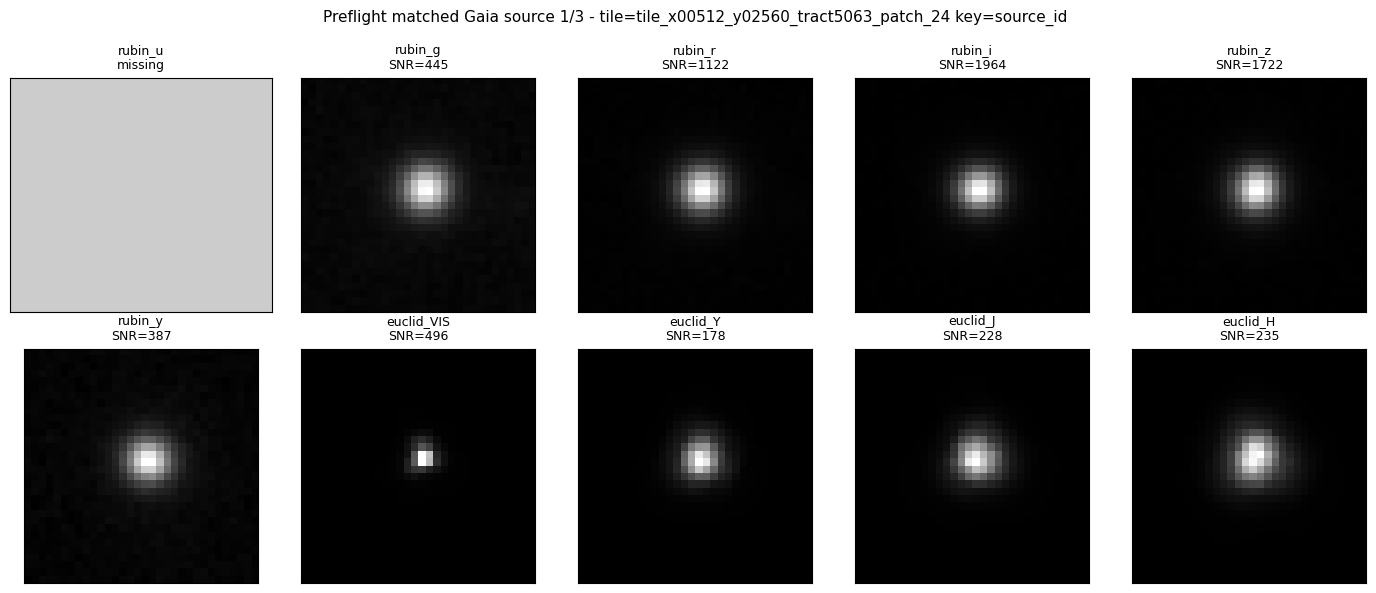

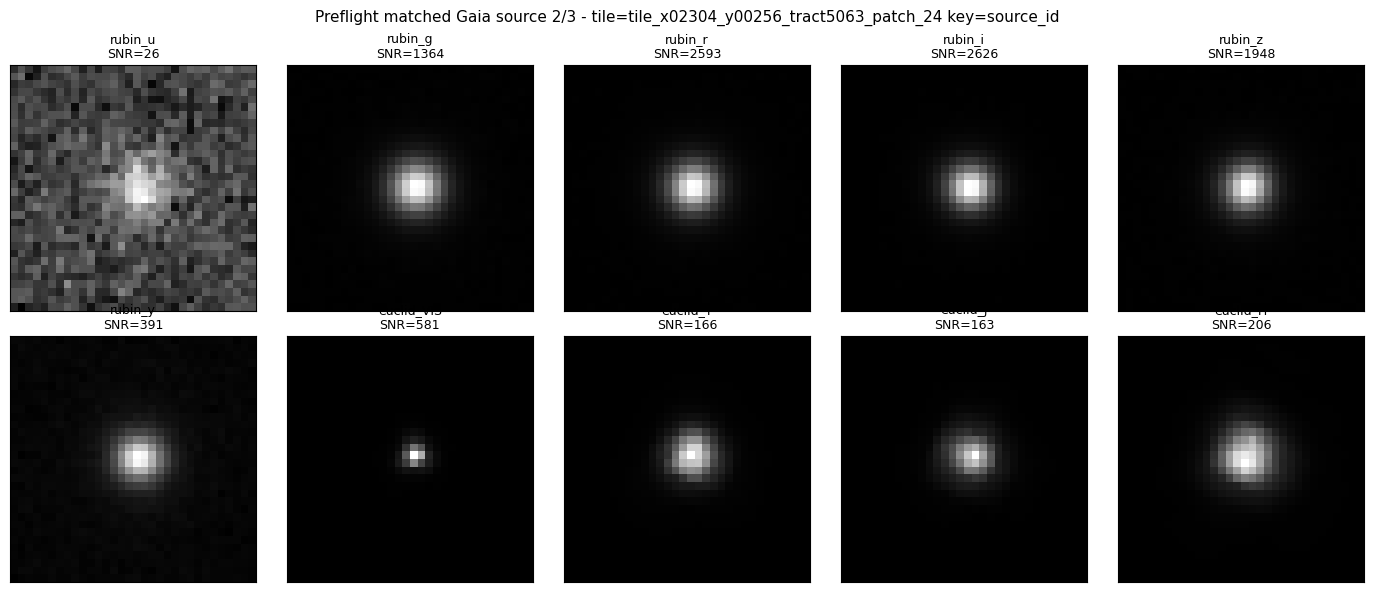

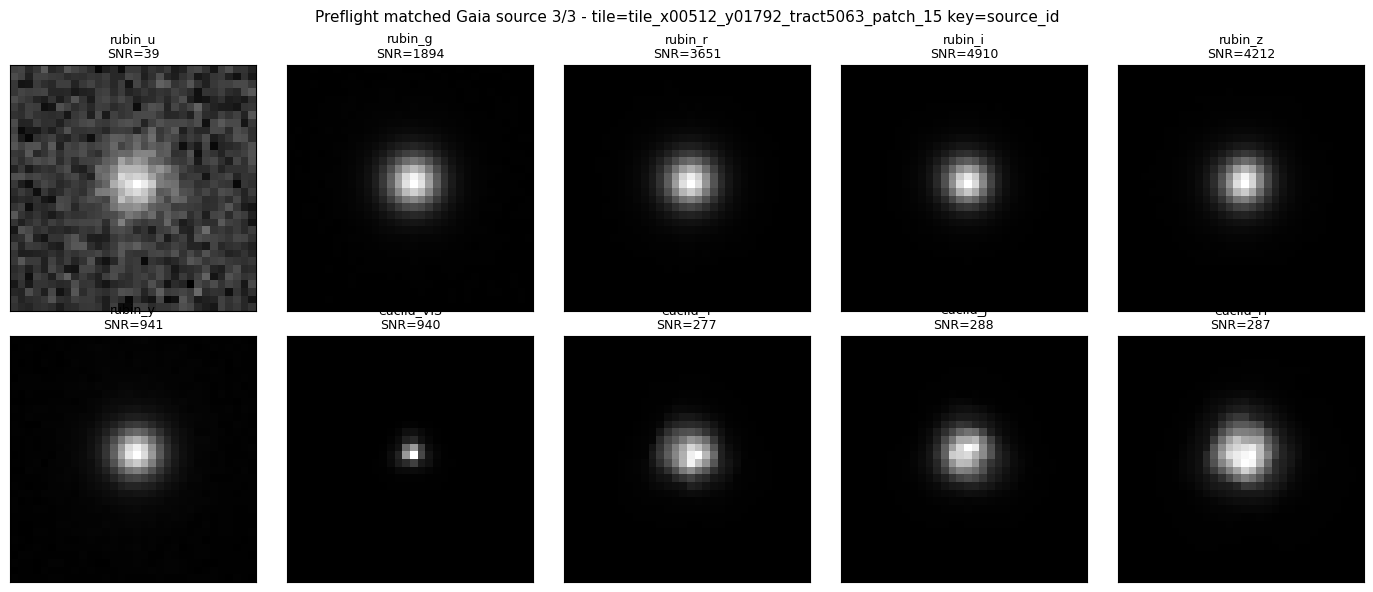


band        median_dx  median_dy   median_r
rubin_r        -0.009      0.015      0.032
rubin_i        -0.016      0.022      0.037
rubin_z        -0.006     -0.002      0.028
euclid_VIS     -0.016      0.056      0.076


/tmp/ipykernel_1690440/3197972960.py:21: RuntimeWarning: All-NaN slice encountered
  bg = float(np.nanmedian(s[bg_mask])) if bg_mask.any() else float(np.nanmedian(s))


euclid_Y        0.059      0.006      0.108
euclid_J        0.056      0.008      0.091
euclid_H        0.056      0.006      0.082


In [7]:
ANCHOR_BAND = "rubin_r"
N_PREFLIGHT = 3
SEED = 42

def _match_source(d, tile, key_name, key_value):
    tile_match = d["tile_id"] == tile
    if key_name in d.files:
        if key_name == "source_id":
            return tile_match & (d[key_name] == key_value)
        return tile_match & (np.abs(d[key_name] - float(key_value)) < 1e-3)
    return np.zeros(d["tile_id"].shape, dtype=bool)

def _centroid_residual(stamp, frac_xy, ap_radius=5.0):
    s = np.asarray(stamp, dtype=np.float64)
    S = s.shape[-1]
    yy, xx = np.indices(s.shape, dtype=np.float64)
    tx = S // 2 + float(frac_xy[0])
    ty = S // 2 + float(frac_xy[1])
    r = np.hypot(xx - tx, yy - ty)
    bg_mask = r > min(14.0, S * 0.38)
    bg = float(np.nanmedian(s[bg_mask])) if bg_mask.any() else float(np.nanmedian(s))
    w = np.clip(s - bg, 0.0, None) * (r < ap_radius)
    total = float(w.sum())
    if total <= 0:
        return np.nan, np.nan, np.nan
    cx = float((xx * w).sum() / total)
    cy = float((yy * w).sum() / total)
    dx = cx - tx
    dy = cy - ty
    return dx, dy, float(np.hypot(dx, dy))

band_data = {}
print(f"TRAIN_DIR = {TRAIN_DIR}")
print(f"{'band':12s} {'n':>7s} {'snr_med':>8s} {'source_id':>10s}")
for band in ALL_BANDS:
    p = TRAIN_DIR / f"{band}.npz"
    if not p.exists():
        band_data[band] = None
        print(f"{band:12s} {'missing':>7s} {'-':>8s} {'-':>10s}")
        continue
    d = np.load(p, allow_pickle=False)
    band_data[band] = d
    n = int(d['stamps'].shape[0])
    snr_med = float(np.nanmedian(d['snr'])) if n > 0 else float('nan')
    has_sid = 'source_id' in d.files
    print(f"{band:12s} {n:7d} {snr_med:8.1f} {str(has_sid):>10s}")

d_anchor = band_data[ANCHOR_BAND]
if d_anchor is None:
    raise FileNotFoundError(f"Missing anchor band file for {ANCHOR_BAND}: {TRAIN_DIR / (ANCHOR_BAND + '.npz')}")
match_key = 'source_id' if 'source_id' in d_anchor.files else 'g_mag'
rng = np.random.RandomState(SEED)
n_pick = min(N_PREFLIGHT, int(d_anchor['stamps'].shape[0]))
anchor_idx = rng.choice(d_anchor['stamps'].shape[0], n_pick, replace=False)

for trial, idx in enumerate(anchor_idx, start=1):
    tile = d_anchor['tile_id'][idx]
    key_value = d_anchor[match_key][idx]
    fig, axes = plt.subplots(2, 5, figsize=(14, 6))
    for ax, band in zip(axes.flat, ALL_BANDS):
        d = band_data.get(band)
        ax.set_xticks([])
        ax.set_yticks([])
        if d is None or match_key not in d.files:
            ax.set_facecolor('#cccccc')
            ax.set_title(f"{band}\nmissing", fontsize=9)
            continue
        m = _match_source(d, tile, match_key, key_value)
        if not m.any():
            ax.set_facecolor('#cccccc')
            ax.set_title(f"{band}\nmissing", fontsize=9)
            continue
        j = int(np.where(m)[0][0])
        s = d['stamps'][j]
        ax.imshow(s, origin='lower', cmap='gray')
        ax.set_title(f"{band}\nSNR={float(d['snr'][j]):.0f}", fontsize=9)
    fig.suptitle(f"Preflight matched Gaia source {trial}/{n_pick} - tile={tile} key={match_key}", fontsize=11)
    plt.tight_layout()
    plt.show()

print()
print(f"{'band':10s} {'median_dx':>10s} {'median_dy':>10s} {'median_r':>10s}")
for band in ['rubin_r', 'rubin_i', 'rubin_z', 'euclid_VIS', 'euclid_Y', 'euclid_J', 'euclid_H']:
    d = band_data.get(band)
    if d is None:
        continue
    S = d['stamps'].shape[-1]
    dxs, dys = [], []
    n_eval = min(2000, int(d['stamps'].shape[0]))
    for stamp, frac in zip(d['stamps'][:n_eval], d['frac_xy'][:n_eval]):
        dx, dy, dr = _centroid_residual(stamp, frac)
        if np.isfinite(dr):
            dxs.append(dx)
            dys.append(dy)
    if not dxs:
        continue
    dxs = np.asarray(dxs)
    dys = np.asarray(dys)
    print(f"{band:10s} {np.median(dxs):10.3f} {np.median(dys):10.3f} {np.median(np.hypot(dxs, dys)):10.3f}")


## 2. Sanity check — same source across all bands (GAIA-anchored)

Stamps are now built from **GAIA DR3 stars** (sub-mas RA/Dec, confirmed point sources via parallax / proper motion / single-source flags) instead of CenterNet detections. Each band's WCS projects (RA, Dec) → pixel coords directly, eliminating the bogus VIS-to-Rubin half-pixel scaling that caused the previous off-centre stamps.

This cell picks 10 random GAIA-anchored sources (anchored on rubin_r) and shows the matched stamp in every band where the source has coverage.

**What to look for:** clean centred star-like cores in every panel. With GAIA you should see this — if you don't, the build pipeline still has a bug.

Empty grey panels = the source isn't in that band's npz (failed SNR cut, edge clip, or no coverage). SNR labelled in red.

Build:
```
PYTHONPATH=models python models/psf/build_psf_gaia_training_set.py \
    --rubin-dir   data/rubin_tiles_all \
    --euclid-dir  data/euclid_tiles_all \
    --out-dir     data/psf_training_gaia \
    --stamp-size  32
```


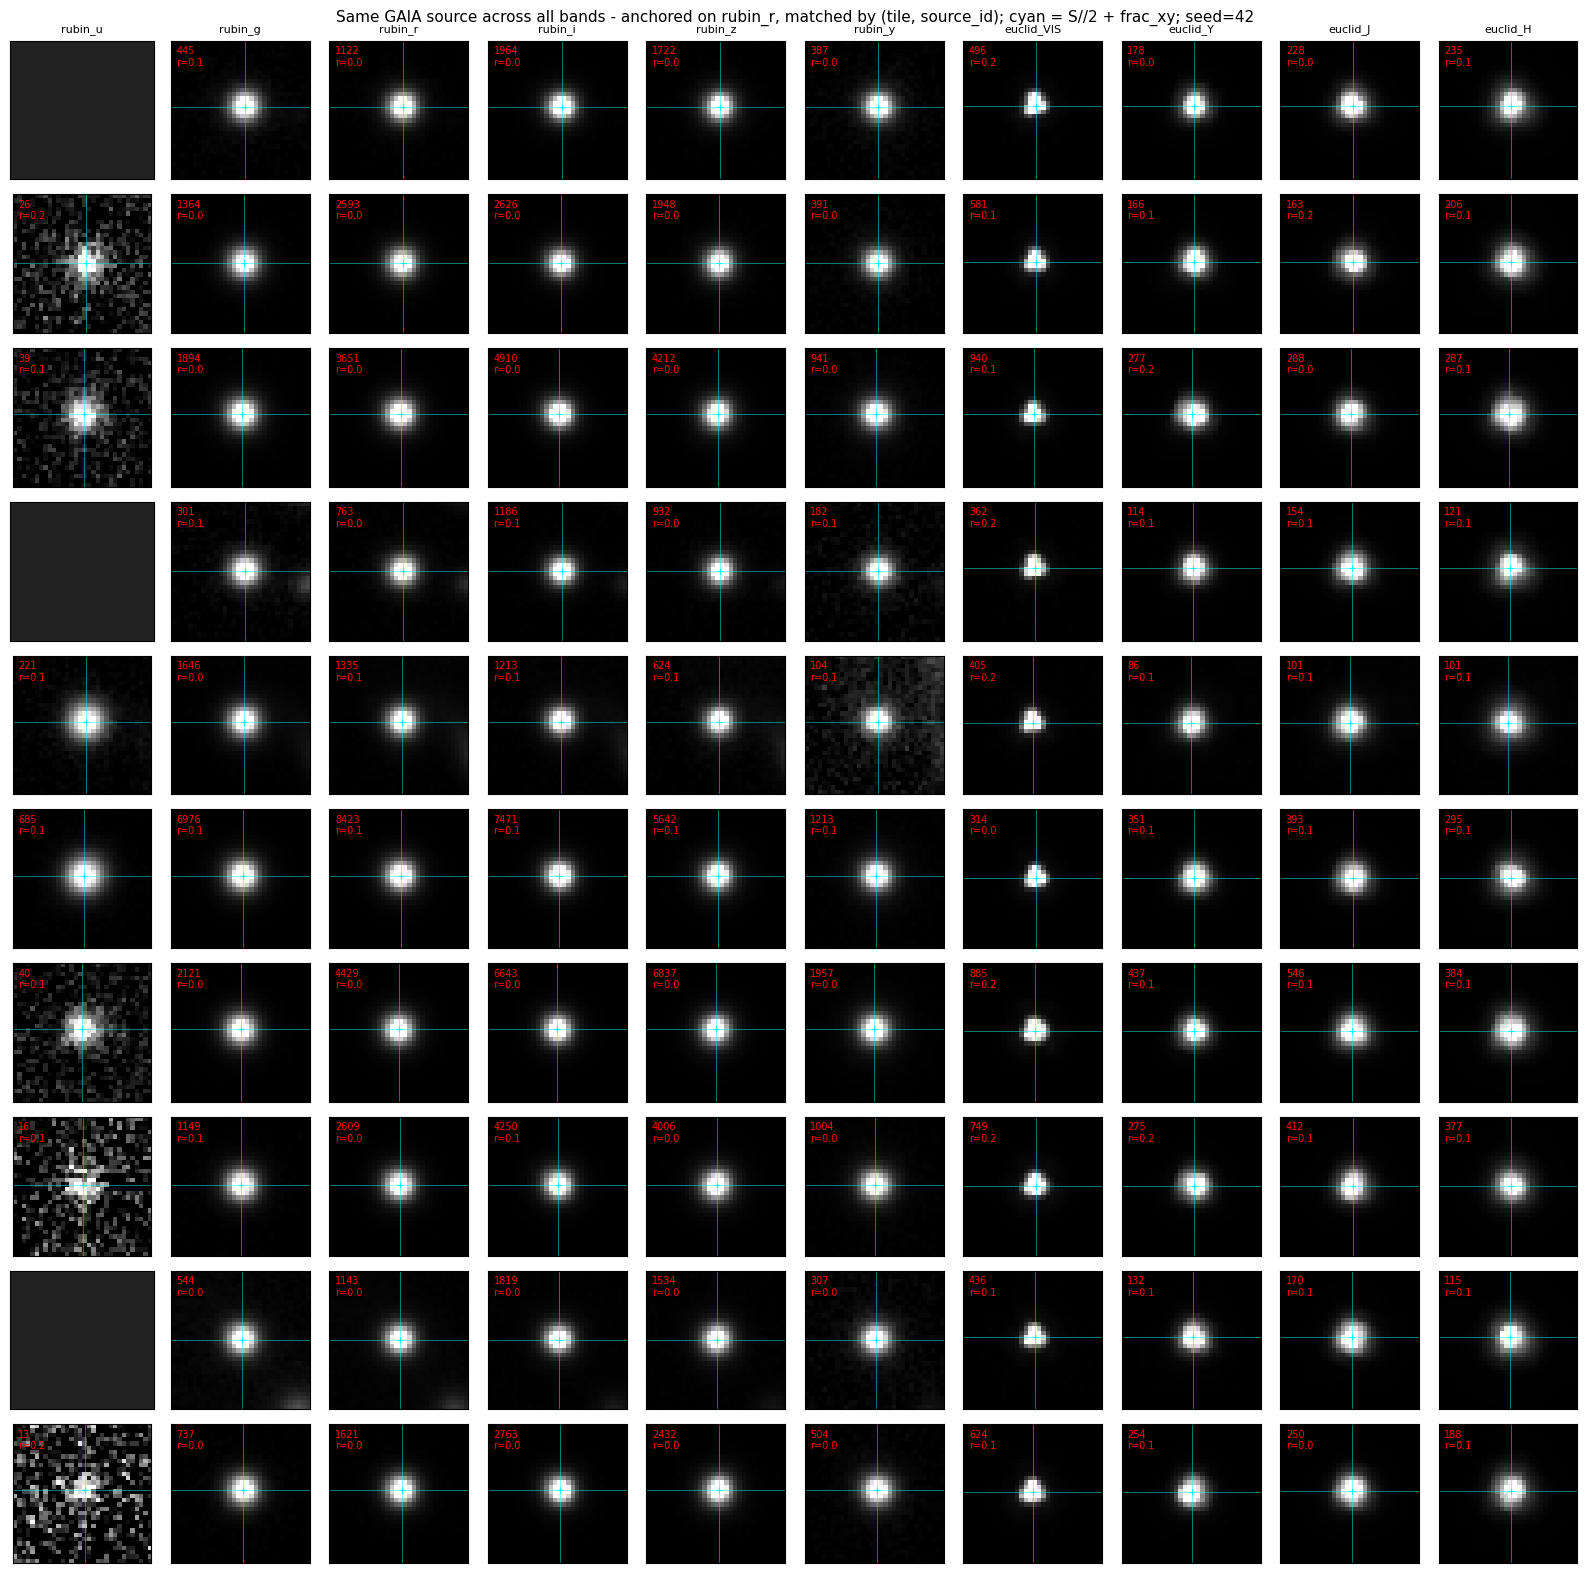

band             n median_r_px  p90_r_px  max_r_px
rubin_u          7       0.089     0.241     0.249
rubin_g         10       0.042     0.079     0.106
rubin_r         10       0.033     0.066     0.077
rubin_i         10       0.038     0.074     0.079
rubin_z         10       0.022     0.055     0.059
rubin_y         10       0.028     0.070     0.074
euclid_VIS      10       0.144     0.193     0.197
euclid_Y        10       0.101     0.152     0.171
euclid_J        10       0.089     0.145     0.219
euclid_H        10       0.087     0.134     0.139


In [8]:
ANCHOR_BAND = "rubin_r"
N_RANDOM = 10
SEED = 42

def _match_source(d, tile, key_name, key_value):
    tile_match = d["tile_id"] == tile
    if key_name in d.files:
        if key_name == "source_id":
            return tile_match & (d[key_name] == key_value)
        return tile_match & (np.abs(d[key_name] - float(key_value)) < 1e-3)
    return np.zeros(d["tile_id"].shape, dtype=bool)

def _centroid_residual(stamp, frac_xy, ap_radius=5.0):
    s = np.asarray(stamp, dtype=np.float64)
    S = s.shape[-1]
    yy, xx = np.indices(s.shape, dtype=np.float64)
    tx = S // 2 + float(frac_xy[0])
    ty = S // 2 + float(frac_xy[1])
    r = np.hypot(xx - tx, yy - ty)
    bg_mask = r > min(14.0, S * 0.38)
    bg = float(np.nanmedian(s[bg_mask])) if bg_mask.any() else float(np.nanmedian(s))
    w = np.clip(s - bg, 0.0, None) * (r < ap_radius)
    total = float(w.sum())
    if total <= 0:
        return np.nan, np.nan, np.nan
    cx = float((xx * w).sum() / total)
    cy = float((yy * w).sum() / total)
    dx = cx - tx
    dy = cy - ty
    return dx, dy, float(np.hypot(dx, dy))

d_anchor = np.load(TRAIN_DIR / f"{ANCHOR_BAND}.npz", allow_pickle=False)
match_key = "source_id" if "source_id" in d_anchor.files else "g_mag"
rng = np.random.RandomState(SEED)
anchor_idx = rng.choice(d_anchor["stamps"].shape[0], N_RANDOM, replace=False)
anchor_tiles = d_anchor["tile_id"][anchor_idx]
anchor_key_values = d_anchor[match_key][anchor_idx]

band_data = {}
for band in PCA_BANDS:
    p = TRAIN_DIR / f"{band}.npz"
    band_data[band] = np.load(p, allow_pickle=False) if p.exists() else None

resid_rows = []
fig, axes = plt.subplots(N_RANDOM, len(PCA_BANDS),
                         figsize=(len(PCA_BANDS) * 1.6, N_RANDOM * 1.6))
for row in range(N_RANDOM):
    tile = anchor_tiles[row]
    key_value = anchor_key_values[row]
    for col, band in enumerate(PCA_BANDS):
        ax = axes[row, col]
        ax.set_xticks([]); ax.set_yticks([])
        if row == 0:
            ax.set_title(band, fontsize=8)
        d = band_data[band]
        if d is None or match_key not in d.files:
            ax.set_facecolor("#222"); continue
        m = _match_source(d, tile, match_key, key_value)
        if not m.any():
            ax.set_facecolor("#222"); continue
        idx = int(np.where(m)[0][0])
        s = d["stamps"][idx]
        frac = d["frac_xy"][idx]
        snr = float(d["snr"][idx])
        dx, dy, dr = _centroid_residual(s, frac)
        resid_rows.append((band, dr, dx, dy, snr))
        vmax = max(float(np.nanpercentile(s, 99)), 1e-6)
        ax.imshow(s, origin="lower", cmap="gray", vmin=0.0, vmax=vmax)
        S = s.shape[-1]
        tx = S // 2 + float(frac[0])
        ty = S // 2 + float(frac[1])
        ax.axhline(ty, color="cyan", alpha=0.55, lw=0.6)
        ax.axvline(tx, color="cyan", alpha=0.55, lw=0.6)
        ax.plot([tx], [ty], marker="+", ms=5, mew=0.8, color="cyan")
        ax.text(0.04, 0.96, f"{snr:.0f}\nr={dr:.1f}", color="red", fontsize=7,
                transform=ax.transAxes, va="top", ha="left",
                bbox=dict(facecolor="black", alpha=0.4, edgecolor="none", pad=1))
fig.suptitle(f"Same GAIA source across all bands - anchored on {ANCHOR_BAND}, matched by (tile, {match_key}); cyan = S//2 + frac_xy; seed={SEED}",
             fontsize=11)
plt.tight_layout(); plt.show()

print(f"{'band':14s} {'n':>3s} {'median_r_px':>11s} {'p90_r_px':>9s} {'max_r_px':>9s}")
for band in PCA_BANDS:
    vals = np.array([r for b, r, _dx, _dy, _snr in resid_rows if b == band and np.isfinite(r)])
    if vals.size == 0:
        print(f"{band:14s} {0:3d}")
        continue
    print(f"{band:14s} {vals.size:3d} {np.median(vals):11.3f} {np.percentile(vals, 90):9.3f} {np.max(vals):9.3f}")


## 2. Load PSFFieldEPSF

Empirical ePSF per band built with photutils.EPSFBuilder. One ePSF per band, no spatial variation (PCA on the same data showed near-zero spatial R²).

Build pipeline behind the scenes:

- Centroids data-derived per stamp (intensity-weighted, brightest-pixel init + iterative refinement). Critical: the refinement starts from the stamp's brightest pixel, not the geometric centre, so it actually finds the source even if the input detection's pixel position is several pixels off.
- Post-rebuild centring check: rejects any stamp whose post-rebuild peak isn't within ±3 native px of the centre.
- Background from sigma-clipped median over wide annulus (8-14 native px), avoiding contamination from the PSF wings.
- Per-band-group SNR cuts: Rubin = 80, Euclid = 30.
- Morphology cut: σ_native ∈ [Q25 · 0.6, Q25 · 1.4].
- psf_size = 99 oversampled.

Reports **core σ** (intensity-weighted within r < 5 native px) — the meaningful metric for stellar photometry. Full-stamp σ is inflated by wing residuals.


In [9]:
from psf.psf_field_pca import PSFFieldEPSF, _core_sigma_mas, ALL_BANDS as PCA_BANDS

PCA_CKPT = ROOT / "models/checkpoints/psf_field_pca/psf_field_pca.pt"
psf_pca = PSFFieldEPSF.load(PCA_CKPT)
print(f"psf_size={psf_pca.psf_size}  oversampling={psf_pca.oversampling}")
print()
PCA_PX_NATIVE = {b: 0.2 if b.startswith("rubin") else 0.1 for b in PCA_BANDS}
print(f"{'band':14s} {'N_train':>8s} {'core σ (mas)':>14s} {'core/total flux':>17s}")
for b in psf_pca.band_names:
    if b not in psf_pca.models: continue
    m = psf_pca.models[b]
    sig_mas, core_frac = _core_sigma_mas(m["data"], psf_pca.oversampling, b)
    print(f"{b:14s} {m['n_train']:8d} {sig_mas:>14.0f} {core_frac:>17.3f}")


ModuleNotFoundError: No module named 'psf.psf_field_pca'

## 3. Per-band ePSF (log scale, core σ in title)

Reconstructed PSF per band. Log colormap (3 decades from peak) with noise floor clipped. Title reports core σ in mas.

Expected band σ (FWHM/2.35): Rubin ~300-400 mas, Euclid VIS ~70-150 mas, Euclid Y/J/H ~170-200 mas.


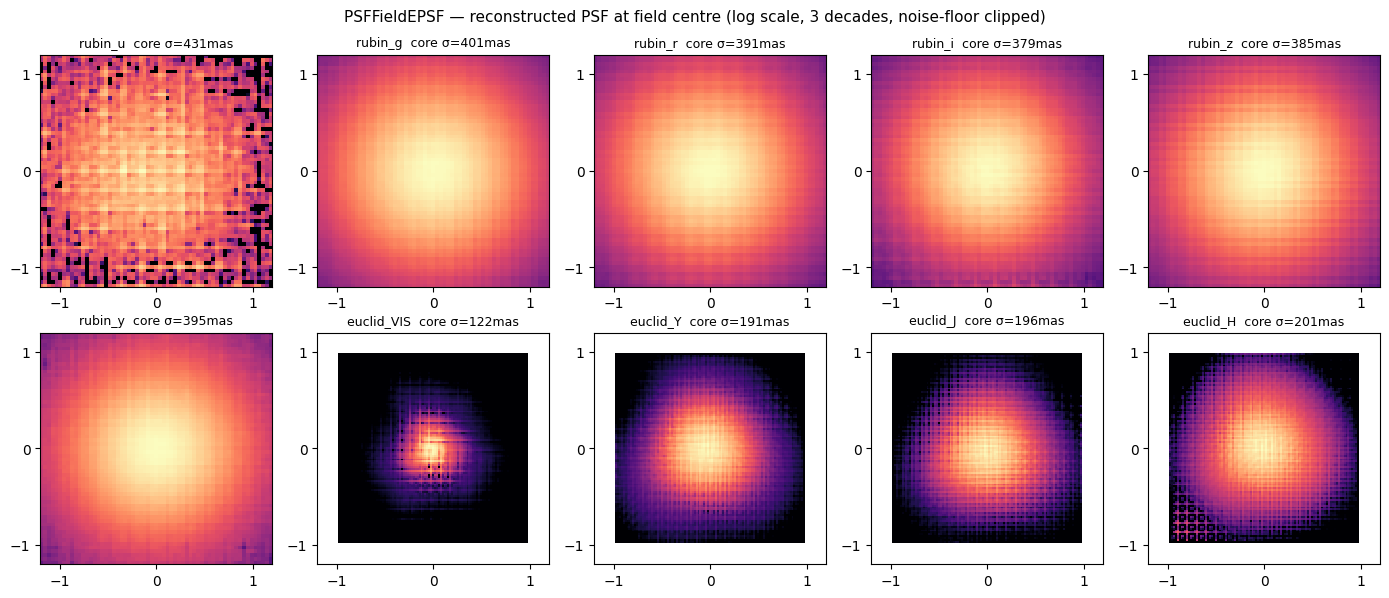

In [ ]:
from matplotlib.colors import LogNorm

PCA_DISPLAY_HALF = 1.2  # arcsec axis half-extent

def pca_render(band):
    bi = PCA_BANDS.index(band)
    psf = psf_pca(torch.zeros(1, 2), torch.tensor([bi]))[0, 0].numpy()
    return psf

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for ax, band in zip(axes.flat, PCA_BANDS):
    if band not in psf_pca.models:
        ax.set_visible(False); continue
    p = pca_render(band)
    P = p.shape[0]
    px_over = PCA_PX_NATIVE[band] / psf_pca.oversampling
    ext = (P - 1) / 2.0 * px_over
    pk = float(p.max())
    # 3-decade log scale; clip everything below vmin to vmin so the wings'
    # noise floor doesn't show up as white holes / striped grid pattern.
    vmin = max(pk * 1e-3, 1e-12)
    p_show = np.clip(p, vmin, pk)
    ax.imshow(p_show, origin="lower", cmap="magma",
              extent=[-ext, ext, -ext, ext],
              norm=LogNorm(vmin=vmin, vmax=pk),
              interpolation="nearest")
    sig_mas, core_frac = _core_sigma_mas(p, psf_pca.oversampling, band)
    ax.set_title(f"{band}  core σ={sig_mas:.0f}mas", fontsize=9)
    ax.set_xlim(-PCA_DISPLAY_HALF, PCA_DISPLAY_HALF)
    ax.set_ylim(-PCA_DISPLAY_HALF, PCA_DISPLAY_HALF)
    ax.set_xticks([-1, 0, 1]); ax.set_yticks([-1, 0, 1])
fig.suptitle("PSFFieldEPSF — reconstructed PSF at field centre (log scale, 3 decades, noise-floor clipped)", fontsize=11)
plt.tight_layout(); plt.show()


## 4. Radial profile per band

Azimuthal-mean radial profile (log-y). Real PSFs fall off rapidly to a noise floor; flat or rising tails at large r mean residual contamination.


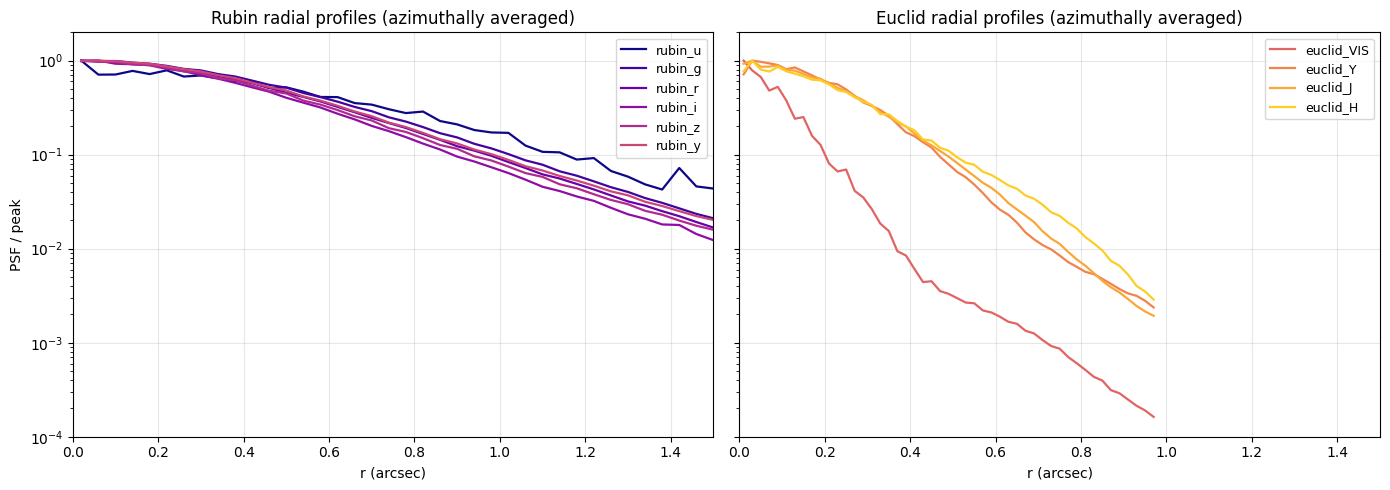

In [ ]:
def radial_profile(psf, n_bins=None):
    P = psf.shape[0]
    half = (P - 1) / 2.0
    if n_bins is None:
        n_bins = max(8, int(half))
    yy, xx = np.indices(psf.shape, dtype=np.float32)
    r = np.sqrt((xx - half) ** 2 + (yy - half) ** 2)
    edges = np.linspace(0, half, n_bins + 1)
    centres, profile = [], []
    for k in range(n_bins):
        m = (r >= edges[k]) & (r < edges[k + 1])
        if m.any():
            centres.append(0.5 * (edges[k] + edges[k + 1]))
            profile.append(float(psf[m].mean()))
    return np.array(centres), np.array(profile)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
colors = plt.cm.plasma(np.linspace(0, 0.9, len(PCA_BANDS)))
for bi, band in enumerate(PCA_BANDS):
    if band not in psf_pca.models:
        continue
    psf = psf_pca(torch.zeros(1, 2), torch.tensor([bi]))[0, 0].numpy()
    r_ovs, prof = radial_profile(psf)
    px_arcsec = (PCA_PX_NATIVE[band] / psf_pca.oversampling)  # arcsec per oversampled px
    r_arcsec = r_ovs * px_arcsec
    prof_norm = prof / max(prof.max(), 1e-12)
    ax = axes[0 if band.startswith("rubin") else 1]
    ax.plot(r_arcsec, prof_norm, color=colors[bi], lw=1.6, label=band)
for ax, title in zip(axes, ["Rubin", "Euclid"]):
    ax.set_yscale("log")
    ax.set_xlim(0, 1.5)
    ax.set_ylim(1e-4, 2)
    ax.set_xlabel("r (arcsec)")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=9)
    ax.set_title(f"{title} radial profiles (azimuthally averaged)")
axes[0].set_ylabel("PSF / peak")
plt.tight_layout(); plt.show()


## 5. Held-out validation — shape match per band

Pearson r and chi^2/dof for the model rendered at the top-5 SNR held-out stars per band. Pearson r is the meaningful comparison number across bands (normalised, shape-only). chi^2/dof grows with stamp brightness — compare *across bands* rather than to 1.


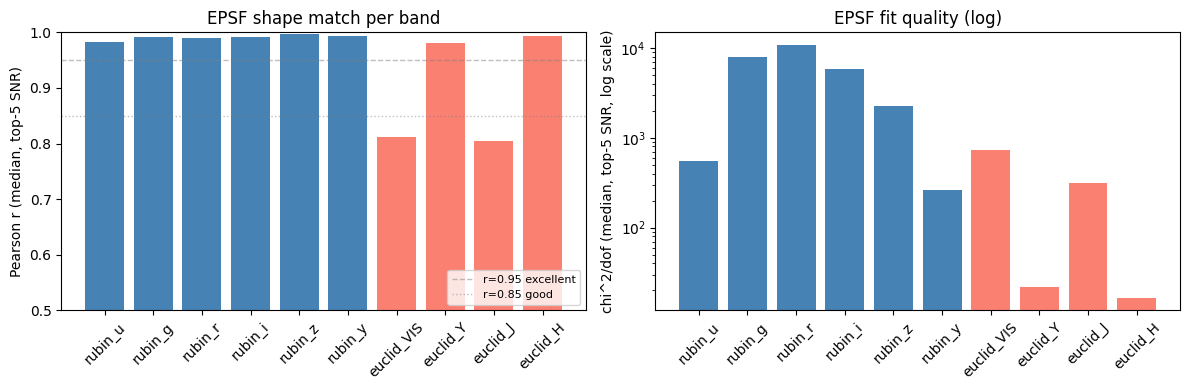


band            N_train  core_sig_mas  n_val        r     chi2/dof
rubin_u             535           431      5   0.983        545.4
rubin_g             757           401      5   0.991       7874.6
rubin_r             757           391      5   0.989      10784.1
rubin_i             757           379      5   0.992       5862.0
rubin_z             757           385      5   0.996       2276.0
rubin_y             757           395      5   0.994        265.1
euclid_VIS          847           122      5   0.812        731.2
euclid_Y            819           191      5   0.981         21.8
euclid_J            806           196      5   0.805        310.1
euclid_H            820           201      5   0.993         16.6


In [ ]:
VALIDATION_DIR = TRAIN_DIR

def _chi2(pred, obs, rms):
    pred = np.nan_to_num(pred, nan=0.0, posinf=0.0, neginf=0.0)
    obs = np.nan_to_num(obs, nan=0.0, posinf=0.0, neginf=0.0)
    rms = np.nan_to_num(rms, nan=np.nanmedian(rms[np.isfinite(rms)]) if np.isfinite(rms).any() else 1.0, posinf=1.0, neginf=1.0)
    inv_var = 1.0 / np.maximum(rms, 1e-6) ** 2
    return float(((pred - obs) ** 2 * inv_var).sum()) / max(int(obs.size - 1), 1)

def _pearson(a, b):
    a = np.nan_to_num(a, nan=0.0, posinf=0.0, neginf=0.0).ravel().astype(np.float64)
    b = np.nan_to_num(b, nan=0.0, posinf=0.0, neginf=0.0).ravel().astype(np.float64)
    a = a - a.mean(); b = b - b.mean()
    den = np.sqrt((a*a).sum()) * np.sqrt((b*b).sum())
    return float((a*b).sum() / max(den, 1e-12))

def _fit_flux_bg(pred, obs, rms):
    pred = np.nan_to_num(pred, nan=0.0, posinf=0.0, neginf=0.0)
    obs = np.nan_to_num(obs, nan=0.0, posinf=0.0, neginf=0.0)
    rms_fill = np.nanmedian(rms[np.isfinite(rms)]) if np.isfinite(rms).any() else 1.0
    rms = np.nan_to_num(rms, nan=rms_fill, posinf=rms_fill, neginf=rms_fill)
    weight = 1.0 / np.maximum(rms, 1e-6) ** 2
    a = float((weight * pred * pred).sum())
    b = float((weight * pred).sum())
    c = float(weight.sum())
    d = float((weight * pred * obs).sum())
    e = float((weight * obs).sum())
    det = max(a * c - b * b, 1e-12)
    flux = max((d * c - b * e) / det, 0.0)
    bg = (a * e - b * d) / det
    return flux * pred + bg

results = {}
for band in PCA_BANDS:
    if band not in psf_pca.models: continue
    path = VALIDATION_DIR / f'{band}.npz'
    if not path.exists(): continue
    d = np.load(path, allow_pickle=False)
    finite_stamp = np.isfinite(d['stamps']).mean(axis=(1, 2)) > 0.95
    finite_rms = np.isfinite(d['rms']).mean(axis=(1, 2)) > 0.95
    valid = np.isfinite(d['snr']) & finite_stamp & finite_rms
    valid_idx = np.where(valid)[0]
    if valid_idx.size < 5: continue
    n_pick = min(5, valid_idx.size)
    order = valid_idx[np.argsort(d['snr'][valid_idx])[::-1][:n_pick]]
    stamps = torch.tensor(d['stamps'][order], dtype=torch.float32)
    rms    = torch.tensor(d['rms'][order],    dtype=torch.float32)
    frac   = torch.tensor(d['frac_xy'][order], dtype=torch.float32)
    pos    = torch.tensor(d['pos_norm'][order], dtype=torch.float32)
    bidx   = torch.full((n_pick,), PCA_BANDS.index(band), dtype=torch.long)
    psf_o = psf_pca(pos, bidx)
    rendered = psf_pca.render_at_native(psf_o, frac, stamp_size=stamps.shape[-1])
    pred = rendered.squeeze(1).numpy()
    obs = stamps.numpy()
    rms_np = rms.numpy()
    scaled = np.stack([_fit_flux_bg(pred[k], obs[k], rms_np[k]) for k in range(n_pick)])
    chi2s = [_chi2(scaled[k], obs[k], rms_np[k]) for k in range(n_pick)]
    rs    = [_pearson(scaled[k], obs[k]) for k in range(n_pick)]
    results[band] = (float(np.median(chi2s)), float(np.median(rs)), int(n_pick))

bands_ok  = list(results.keys())
chi2_vals = [results[b][0] for b in bands_ok]
r_vals    = [results[b][1] for b in bands_ok]
colors    = ['steelblue' if b.startswith('rubin') else 'salmon' for b in bands_ok]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(bands_ok, r_vals, color=colors)
axes[0].set_ylabel('Pearson r (median, top-5 SNR)')
axes[0].set_title('EPSF shape match per band')
axes[0].set_ylim(0.5, 1.0)
axes[0].axhline(0.95, color='gray', ls='--', lw=1, alpha=0.5, label='r=0.95 excellent')
axes[0].axhline(0.85, color='gray', ls=':',  lw=1, alpha=0.5, label='r=0.85 good')
axes[0].legend(fontsize=8, loc='lower right')
axes[1].bar(bands_ok, chi2_vals, color=colors)
axes[1].set_yscale('log')
axes[1].set_ylabel('chi^2/dof (median, top-5 SNR, log scale)')
axes[1].set_title('EPSF fit quality (log)')
for ax in axes:
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout(); plt.show()

print()
print(f'{"band":14s} {"N_train":>8s} {"core_sig_mas":>13s} {"n_val":>6s}   {"r":>6s}   {"chi2/dof":>10s}')
for band in bands_ok:
    chi2_v, r_v, n_pick = results[band]
    m = psf_pca.models[band]
    core_sig_mas, _core_frac = _core_sigma_mas(m['data'], psf_pca.oversampling, band)
    print(f'{band:14s} {m["n_train"]:8d} {core_sig_mas:13.0f} {n_pick:6d}   '
          f'{r_v:.3f}   {chi2_v:>10.1f}')
